# Benchmarking – Baseline Simulation Studies:
## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

import multiprocessing
import os, random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)


def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass

    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 3

    return max(1, n_cores - 1)


N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

PROVIDE_TEX_OUTPUT = True

Using N_JOBS=10 for parallel processing.


In [3]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


### 1.2) Helper-Functions:

In [4]:
from benchmarking_runners import benchmark_cluster_metrics, benchmark_scaling
from benchmarking_plotting import (
    plot_examples,
    plot_ari_over_difficulty,
    plot_paper_figure,
    plot_runtime_over_axis,
    filter_true_k,
    draw_grouped_legend,
)
from benchmarking_reporting import (
    summarize_regime_tables,
    summarize_scaling_tables,
    summarize_scaling_runtime_table,
)
from benchmarking_summary_functions import print_tex_blocks

---

## 2) Default Benchmarks:

### 2.1) Gaussians Mixtures:

In [5]:
anchor_settings_gaussians = {
    "easy": {"cluster_scale": [4.0] * 5, "cluster_size_dirichlet_alpha": 0.9},
    "medium": {"cluster_scale": [4.5] * 5, "cluster_size_dirichlet_alpha": 0.5},
    "hard": {"cluster_scale": [4.6] * 5, "cluster_size_dirichlet_alpha": 0.1},
}

other_settings_gaussians = {"n_total": 1500, "p": 50}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_gaussians,
    other_settings=other_settings_gaussians,
    estimator_type="kmeans",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [6]:
results_path = "../results/results_gaussian.csv"

if not os.path.exists(results_path):
    results_gaussian = benchmark_cluster_metrics(
        anchor_settings_gaussians,
        other_settings_gaussians,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian.to_csv(results_path, index=False)

else:
    results_gaussian = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    anchor_settings_gaussians,
    other_settings_gaussians,
    get_snapshot=True,
    snapshot_df=results_gaussian,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED + 1,
)

_ = plot_ari_over_difficulty(results_gaussian, dodge=0.01)

In [ ]:
tables_gaussian = summarize_regime_tables(results_gaussian, true_k=5)
display(tables_gaussian["ari_df"])
display(tables_gaussian["k_recovery_df"])
print_tex_blocks(
    tables_gaussian, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT
)

---

### 2.2) t-Distributed Mixtures:

In [7]:
anchor_settings_t_dist = {
    "easy": {
        "cluster_scale": [3.5, 1.0, 1.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.9,
        "t_df": 5,
    },
    "medium": {
        "cluster_scale": [3.0, 1.5, 1.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.3,
        "t_df": 3,
    },
    "hard": {
        "cluster_scale": [4.0, 3.0, 2.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.1,
        "t_df": 3,
    },
}

other_settings_t_dist = {"n_total": 1500, "p": 50, "distribution": "t"}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_t_dist,
    other_settings=other_settings_t_dist,
    estimator_type="agglomerative",
    example_title="t-Distributed Mixtures",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [8]:
results_path = "../results/results_t_dist.csv"

if not os.path.exists(results_path):
    results_t_dist = benchmark_cluster_metrics(
        anchor_settings_t_dist,
        other_settings_t_dist,
        estimator="agglomerative",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_t_dist.to_csv(results_path, index=False)

else:
    results_t_dist = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    anchor_settings_t_dist,
    other_settings_t_dist,
    estimator="agglomerative",
    get_snapshot=True,
    snapshot_df=results_t_dist,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_t_dist, dodge=0.01)

In [ ]:
tables_t_dist = summarize_regime_tables(results_t_dist, true_k=5)
display(tables_t_dist["ari_df"])
display(tables_t_dist["k_recovery_df"])
print_tex_blocks(tables_t_dist, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT)

---

### 2.3) t-Distributed Mixtures with Nuisance Dimensions:

In [9]:
anchor_settings_t_dist_noise = {
    "easy": {
        "cluster_scale": [1.0] * 5,
        "cluster_size_dirichlet_alpha": 0.9,
        "t_df": 5,
        "corr_strength": 0.1,
        "noise_dims": 512,
    },
    "medium": {
        "cluster_scale": [1.1, 1.0, 1.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.3,
        "t_df": 4,
        "corr_strength": 0.3,
        "noise_dims": 1280,
    },
    "hard": {
        "cluster_scale": [1.1, 1.0, 1.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.1,
        "t_df": 3,
        "corr_strength": 0.5,
        "noise_dims": 1536,
    },
}

other_settings_t_dist_noise = {
    "n_total": 1500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "t",
}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_t_dist_noise,
    other_settings=other_settings_t_dist_noise,
    estimator_type="agglomerative",
    example_title="t-Distributed Mixtures with Nuisance Dimensions",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [10]:
results_path = "../results/results_t_dist_noise.csv"

if not os.path.exists(results_path):
    results_t_dist_noise = benchmark_cluster_metrics(
        anchor_settings_t_dist_noise,
        other_settings_t_dist_noise,
        estimator="agglomerative",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_t_dist_noise.to_csv(results_path, index=False)

else:
    results_t_dist_noise = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    anchor_settings_t_dist_noise,
    other_settings_t_dist_noise,
    estimator="agglomerative",
    get_snapshot=True,
    snapshot_df=results_t_dist_noise,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED + 2,
)

_ = plot_ari_over_difficulty(results_t_dist_noise, dodge=0.01)

In [ ]:
tables_t_dist_noise = summarize_regime_tables(results_t_dist_noise, true_k=5)
display(tables_t_dist_noise["ari_df"])
display(tables_t_dist_noise["k_recovery_df"])
print_tex_blocks(
    tables_t_dist_noise, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT
)

---

### 2.4) RFF Embedded Circles:

In [11]:
anchor_settings_circles = {
    "easy": {
        "cluster_scale": [4.08, 4.08, 3.0, 3.0, 3.0],
        "cluster_size_dirichlet_alpha": 0.9,
        "corr_strength": 0.1,
        "embed_param": 12.0,
    },
    "medium": {
        "cluster_scale": [4.08, 4.08, 3.0, 3.0, 3.0],
        "cluster_size_dirichlet_alpha": 0.61,
        "corr_strength": 0.23,
        "embed_param": 7.3,
    },
    "hard": {
        "cluster_scale": [4.38, 4.08, 4.08, 4.08, 4.08],
        "cluster_size_dirichlet_alpha": 0.35,
        "corr_strength": 0.20,
        "embed_param": 6.0,
    },
}

other_settings_circles = {
    "distribution": "circles",
    "nonlinear": True,
    "n_total": 1500,
    "p": 50,
    "corr_type": "ar1",
    "embed_dim": 64,
}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_circles,
    other_settings=other_settings_circles,
    estimator_type="spectral",
    example_title="RFF Embedded Circles",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [12]:
results_path = "../results/results_circles.csv"

if not os.path.exists(results_path):
    results_circles = benchmark_cluster_metrics(
        anchor_settings=anchor_settings_circles,
        other_settings=other_settings_circles,
        estimator="spectral",
        n_trees=500,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_circles.to_csv(results_path, index=False)

else:
    results_circles = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    anchor_settings_circles,
    other_settings_circles,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_circles,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_circles, dodge=0.01)

In [ ]:
tables_circles = summarize_regime_tables(results_circles, true_k=5)
display(tables_circles["ari_df"])
display(tables_circles["k_recovery_df"])
print_tex_blocks(
    tables_circles, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT
)

---

### 2.5) RFF Embedded Moons:

In [13]:
anchor_settings_moons = {
    "easy": {
        "cluster_scale": [5.5, 3.97, 3.97, 3.97, 3.97],
        "cluster_size_dirichlet_alpha": 0.67,
        "corr_strength": 0.39,
        "embed_param": 10.7,
    },
    "medium": {
        "cluster_scale": [4.8, 4.06, 4.06, 4.06, 4.06],
        "cluster_size_dirichlet_alpha": 0.57,
        "corr_strength": 0.30,
        "embed_param": 5.7,
    },
    "hard": {
        "cluster_scale": [4.06, 2.65, 2.65, 2.65, 2.65],
        "cluster_size_dirichlet_alpha": 0.10,
        "corr_strength": 0.16,
        "embed_param": 14.5,
    },
}

other_settings_moons = {
    "distribution": "moons",
    "nonlinear": True,
    "n_total": 1500,
    "p": 50,
    "corr_type": "ar1",
    "embed_dim": 64,
}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_moons,
    other_settings=other_settings_moons,
    estimator_type="spectral",
    example_title="RFF Embedded Moons",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [14]:
results_path = "../results/results_moons.csv"

if not os.path.exists(results_path):
    results_moons = benchmark_cluster_metrics(
        anchor_settings_moons,
        other_settings_moons,
        estimator="spectral",
        n_trees=500,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_moons.to_csv(results_path, index=False)

else:
    results_moons = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    anchor_settings_moons,
    other_settings_moons,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_moons,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_moons, dodge=0.01)

In [ ]:
tables_moons = summarize_regime_tables(results_moons, true_k=5)
display(tables_moons["ari_df"])
display(tables_moons["k_recovery_df"])
print_tex_blocks(tables_moons, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT)

---

### 2.6) RFF Embedded Swiss Rolls:

In [15]:
anchor_settings_swiss_rolls = {
    "easy": {
        "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.9,
        "corr_strength": 0.1,
        "embed_param": 8.0,
    },
    "medium": {
        "cluster_scale": [2.0, 2.0, 1.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.7,
        "corr_strength": 0.1,
        "embed_param": 5.0,
    },
    "hard": {
        "cluster_scale": [2.0, 2.0, 1.0, 1.0, 1.0],
        "cluster_size_dirichlet_alpha": 0.5,
        "corr_strength": 0.3,
        "embed_param": 5.0,
    },
}

other_settings_swiss_rolls = {
    "distribution": "swiss_roll",
    "nonlinear": True,
    "n_total": 1500,
    "p": 50,
    "corr_type": "ar1",
    "embed_dim": 64,
    "center_box": 3.0,
}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_swiss_rolls,
    other_settings=other_settings_swiss_rolls,
    estimator_type="agglomerative",
    example_title="RFF Embedded Swiss Rolls",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [16]:
results_path = "../results/results_swiss_rolls.csv"

if not os.path.exists(results_path):
    results_swiss_rolls = benchmark_cluster_metrics(
        anchor_settings_swiss_rolls,
        other_settings_swiss_rolls,
        estimator="agglomerative",
        n_trees=500,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_swiss_rolls.to_csv(results_path, index=False)

else:
    results_swiss_rolls = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    anchor_settings_swiss_rolls,
    other_settings_swiss_rolls,
    estimator="agglomerative",
    get_snapshot=True,
    snapshot_df=results_swiss_rolls,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_swiss_rolls, dodge=0.01)

In [ ]:
tables_swiss_rolls = summarize_regime_tables(results_swiss_rolls, true_k=5)
display(tables_swiss_rolls["ari_df"])
display(tables_swiss_rolls["k_recovery_df"])
print_tex_blocks(
    tables_swiss_rolls, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT
)

---

## 3) Scalability Benchmarks:

### 3.1) Gaussians Mixtures:

#### 3.1.1) Dimensionality:

In [17]:
anchor_settings_gaussians_dimensionality = {
    "start": {"cluster_scale": [4.3] * 5},
    "middle": {"cluster_scale": [10.5] * 5},
    "end": {"cluster_scale": [12.2] * 5},
}

other_settings_gaussians_dimensionality = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_gaussians_dimensionality,
    other_settings=other_settings_gaussians_dimensionality,
    level_label="p",
    example_title="Gaussian Mixtures (Increasing Dimensionality)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [18]:
results_path = "../results/scalability_results/results_gaussian_dimensionality.csv"
runtimes_path = "../results/scalability_results/runtimes_gaussian_dimensionality.csv"

if not os.path.exists(results_path):
    results_gaussian_dimensionality, runtimes_gaussian_dimensionality = (
        benchmark_scaling(
            anchor_settings_gaussians_dimensionality,
            other_settings_gaussians_dimensionality,
            axis_name="p",
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
        )
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian_dimensionality.to_csv(results_path, index=False)
    runtimes_gaussian_dimensionality.to_csv(runtimes_path, index=False)

else:
    results_gaussian_dimensionality = pd.read_csv(results_path)
    runtimes_gaussian_dimensionality = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(results_gaussian_dimensionality, dodge=0.01)

#### 3.1.2) Number of Samples:

In [19]:
anchor_settings_gaussians_samples = {
    "start": {"cluster_scale": [4.2] * 5},
    "middle": {"cluster_scale": [4.4] * 5},
    "end": {"cluster_scale": [4.5] * 5},
}

other_settings_gaussians_samples = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
}

In [ ]:
plot_examples(
    anchor_settings=anchor_settings_gaussians_samples,
    other_settings=other_settings_gaussians_samples,
    level_label="n_total",
    example_title="Gaussian Mixtures (Increasing Number of Samples)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [20]:
results_path = "../results/scalability_results/results_gaussian_samples.csv"
runtimes_path = "../results/scalability_results/runtimes_gaussian_samples.csv"

if not os.path.exists(results_path):
    results_gaussian_samples, runtimes_gaussian_samples = benchmark_scaling(
        anchor_settings_gaussians_samples,
        other_settings_gaussians_samples,
        axis_name="n_total",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian_samples.to_csv(results_path, index=False)
    runtimes_gaussian_samples.to_csv(runtimes_path, index=False)

else:
    results_gaussian_samples = pd.read_csv(results_path)
    runtimes_gaussian_samples = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(results_gaussian_samples, dodge=0.01)

---

## 4) Overview – All Regimes:

### Paper Figure 3 — Per-k* Overview (Examples + Lineplots):

In [21]:
regimes = [
    ("Gaussians", results_gaussian),
    ("t-Distributed", results_t_dist),
    ("t-Distributed + Nuisance Dims", results_t_dist_noise),
    ("RFF Circles", results_circles),
    ("RFF Moons", results_moons),
    ("RFF Swiss Rolls", results_swiss_rolls),
]

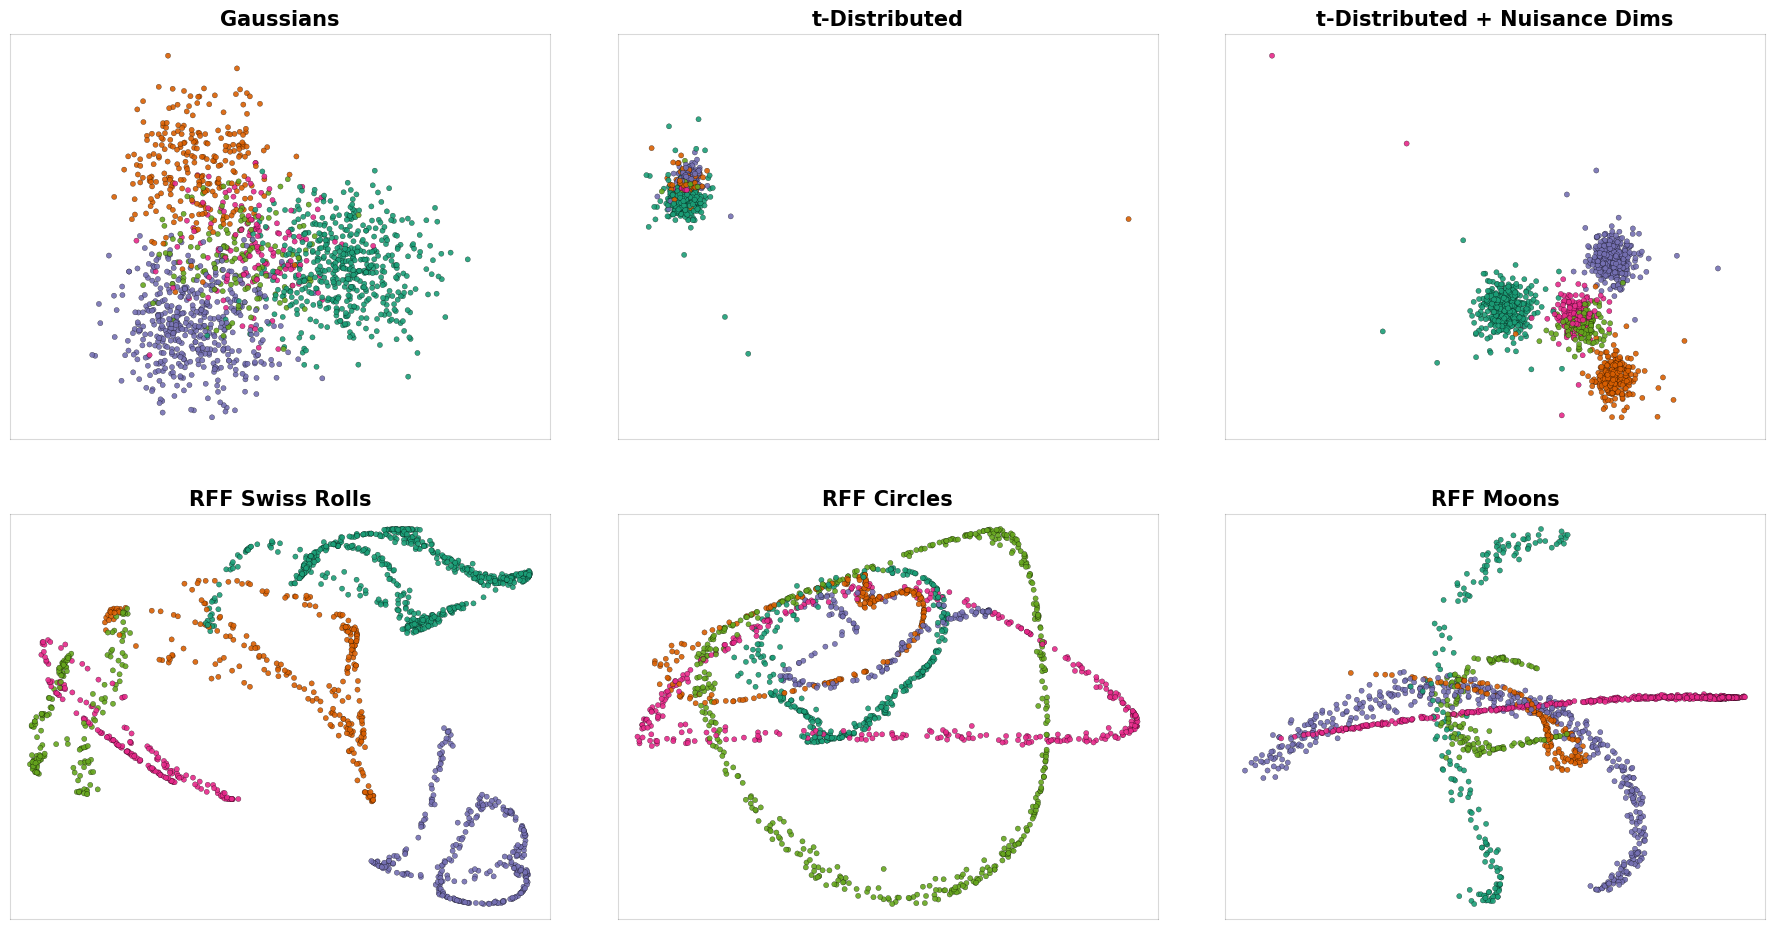

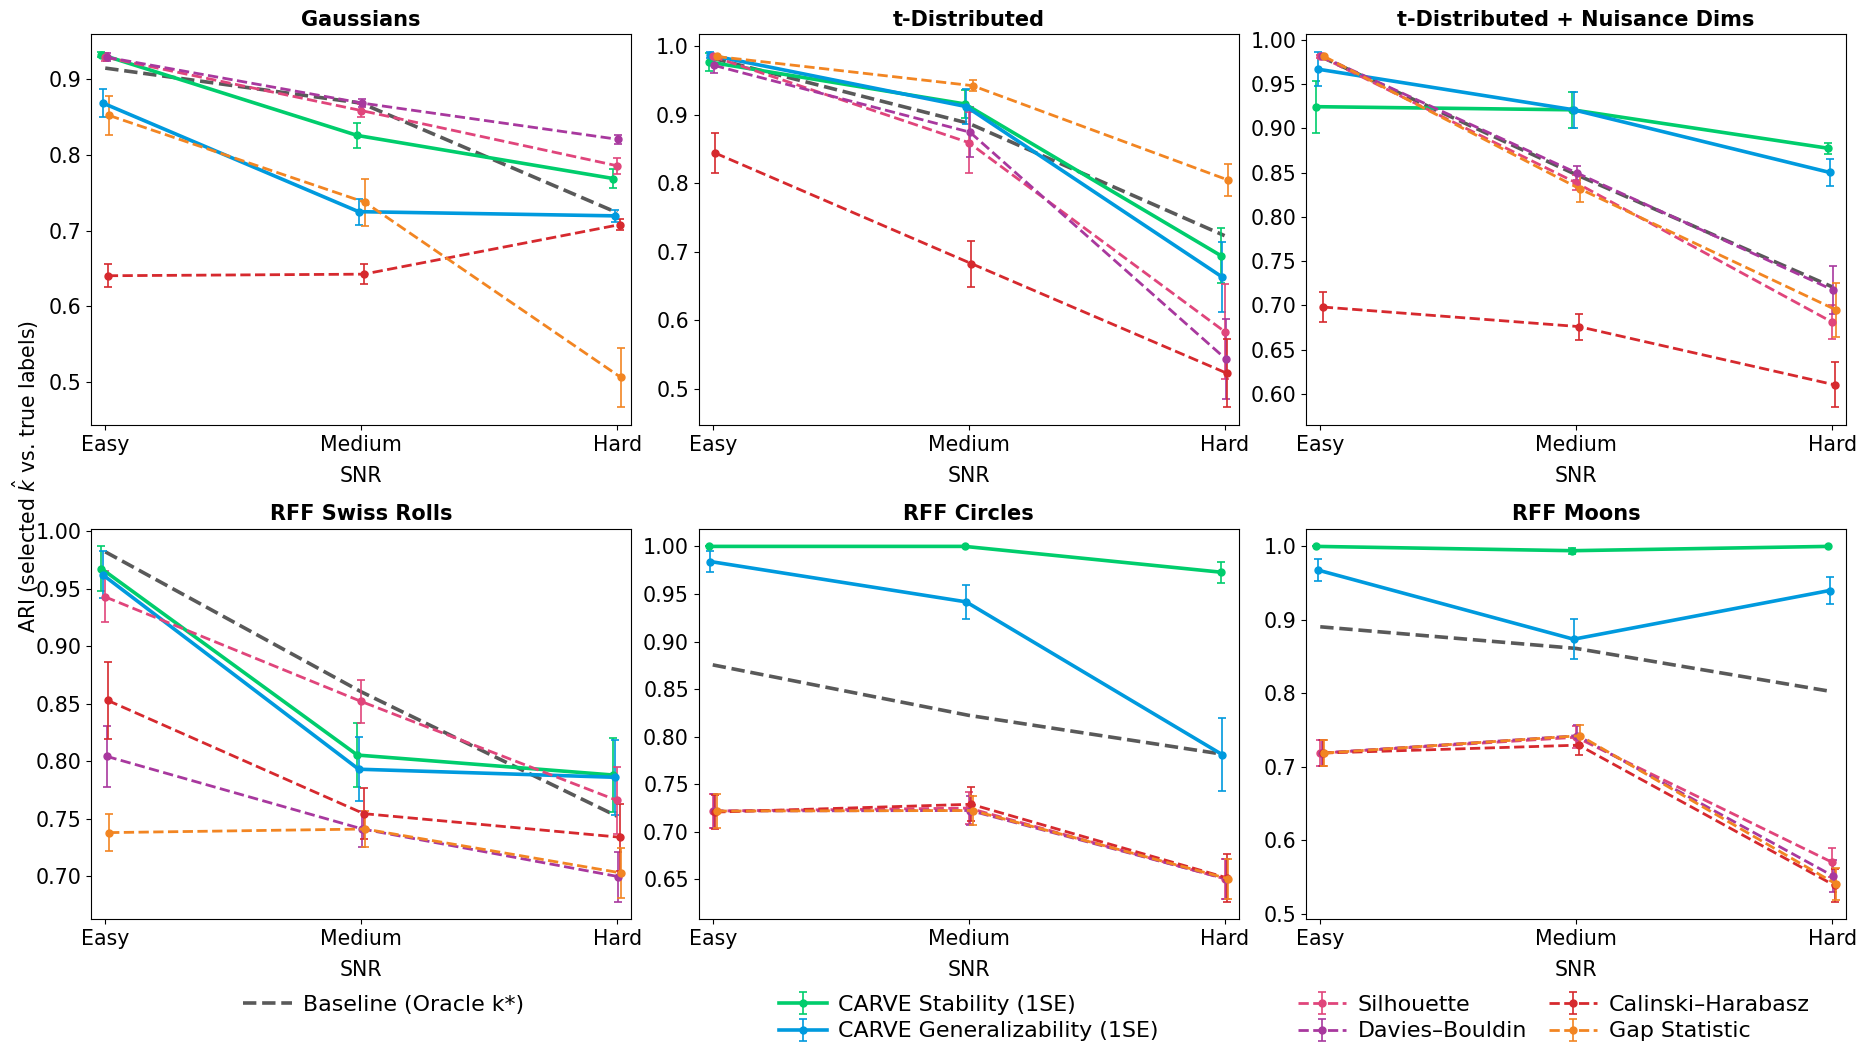

In [22]:
regimes_full = [
    (
        "Gaussians",
        results_gaussian,
        anchor_settings_gaussians,
        other_settings_gaussians,
        "kmeans",
    ),
    (
        "t-Distributed",
        results_t_dist,
        anchor_settings_t_dist,
        other_settings_t_dist,
        "agglomerative",
    ),
    (
        "t-Distributed + Nuisance Dims",
        results_t_dist_noise,
        anchor_settings_t_dist_noise,
        other_settings_t_dist_noise,
        "agglomerative",
    ),
    (
        "RFF Swiss Rolls",
        results_swiss_rolls,
        anchor_settings_swiss_rolls,
        other_settings_swiss_rolls,
        "spectral",
    ),
    (
        "RFF Circles",
        results_circles,
        anchor_settings_circles,
        other_settings_circles,
        "spectral",
    ),
    (
        "RFF Moons",
        results_moons,
        anchor_settings_moons,
        other_settings_moons,
        "spectral",
    ),
]

os.makedirs("../vis/benchmarking/", exist_ok=True)

K_STAR = 5
for panels in ("A", "B"):
    fig = plot_paper_figure(
        regimes_full,
        k_star=K_STAR,
        panels=panels,
        difficulty="hard",
        metrics=(
            "ari_stability_1se",
            "ari_generalizability_1se",
            "silhouette",
            "gap",
            "davies_bouldin",
            "calinski_harabasz",
        ),
        center="mean",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
        scale=1.5,
        tick_fontsize=14.8,  # axis labels + ticks, matched to scaling plots
        legend_fontsize=15.9,  # a tad bigger than before
    )
    fig.savefig(
        f"../vis/benchmarking/paper_fig3_k{K_STAR}_{panels}.png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()

### Section 3 Scaling — ARI & Runtime 2×2 Grids:

Per-`k★` paper figures consolidating the four scaling experiments from section 3. Rows: `n_total` (top) vs. `p`/`embed_dim` (bottom). Columns: Gaussian Mixtures (left) vs. RFF Embedded Moons (right).

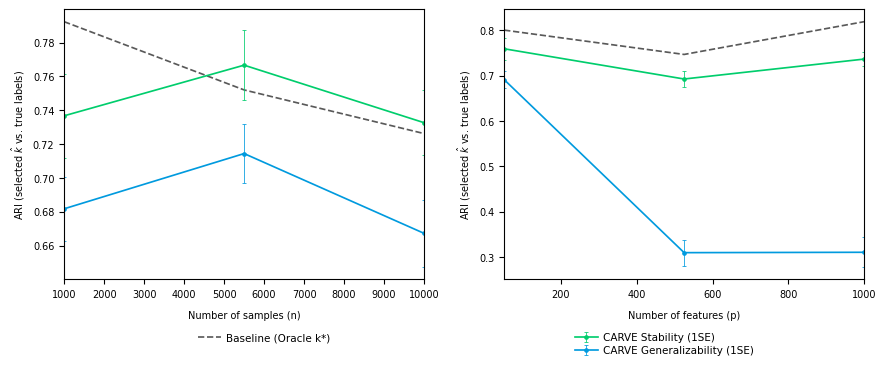

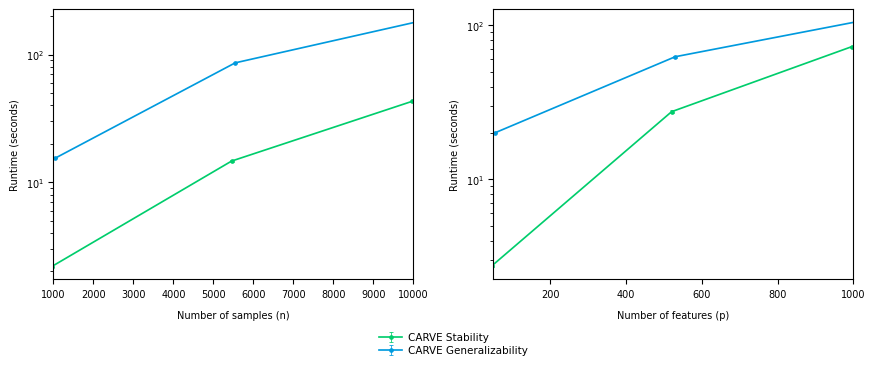

In [23]:
os.makedirs("../vis/benchmarking/", exist_ok=True)

K_STAR = 5

CELL_W, CELL_H = 3.6, 2.7
GAP_H, GAP_V = 0.80, 0.50
MARGIN_L, MARGIN_R = 0.65, 0.20
MARGIN_T, MARGIN_B = 0.20, 1.60
LABEL_FS = 7.0  # axis labels + tick numbers, a tad bigger
LEGEND_FS = 7.5  # grouped legend, a tad bigger
ELEMENT_SCALE = 0.47  # scale line/marker widths to match Fig 4 apparent thickness


def _scaling_figsize(nrows, ncols):
    w = MARGIN_L + ncols * CELL_W + (ncols - 1) * GAP_H + MARGIN_R
    h = MARGIN_T + nrows * CELL_H + (nrows - 1) * GAP_V + MARGIN_B
    return w, h


def _scaling_adjust(fig):
    w, h = fig.get_size_inches()
    fig.subplots_adjust(
        left=MARGIN_L / w,
        right=1.0 - MARGIN_R / w,
        bottom=MARGIN_B / h,
        top=1.0 - MARGIN_T / h,
        wspace=GAP_H / CELL_W,
        hspace=GAP_V / CELL_H,
    )


# ----- ARI grid -----------------------------------------------------------
panels_ari = [
    [("Gaussian Mixtures", results_gaussian_samples, "Number of samples (n)")],
    [("Gaussian Mixtures", results_gaussian_dimensionality, "Number of features (p)")],
    # [("RFF Embedded Moons", results_moons_samples,        "Number of samples (n)")],
    # [("RFF Embedded Moons", results_moons_dimensionality, "Embedding dimensions")],
]
nrows, ncols = len(panels_ari[0]), len(panels_ari)
fig_ari, axes_ari = plt.subplots(
    nrows, ncols, figsize=_scaling_figsize(nrows, ncols), squeeze=False
)
for r, row in enumerate(panels_ari):
    for c, (name, df, x_label) in enumerate(row):
        ax = axes_ari[c, r]
        df_k = filter_true_k(df, K_STAR)
        if df_k.empty:
            ax.set_visible(False)
            continue
        plot_ari_over_difficulty(
            df_k,
            x_label=x_label,
            x_label_font_size=LABEL_FS,
            title=None,
            ax=ax,
            show_legend=False,
            element_scale=ELEMENT_SCALE,
            metrics=("ari_stability_1se", "ari_generalizability_1se"),
        )
        ax.tick_params(labelsize=LABEL_FS)
        if c == 0:
            ax.set_ylabel(
                r"ARI (selected $\hat{k}$ vs. true labels)", fontsize=LABEL_FS
            )
        else:
            ax.set_ylabel("")

_scaling_adjust(fig_ari)
draw_grouped_legend(fig_ari, axes_ari, fontsize=LEGEND_FS, legend_y_offset=0.10)
fig_ari.savefig(
    f"../vis/benchmarking/paper_fig_scaling_ari_k{K_STAR}.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

# ----- Runtime grid -------------------------------------------------------
panels_rt = [
    [("Gaussian Mixtures", runtimes_gaussian_samples, "Number of samples (n)")],
    [("Gaussian Mixtures", runtimes_gaussian_dimensionality, "Number of features (p)")],
    # [("RFF Embedded Moons", runtimes_moons_samples,        "Number of samples (n)")],
    # [("RFF Embedded Moons", runtimes_moons_dimensionality, "Embedding dimensions")],
]
nrows, ncols = len(panels_rt[0]), len(panels_rt)
fig_rt, axes_rt = plt.subplots(
    nrows, ncols, figsize=_scaling_figsize(nrows, ncols), squeeze=False
)
for r, row in enumerate(panels_rt):
    for c, (name, df, x_label) in enumerate(row):
        ax = axes_rt[c, r]
        df_k = filter_true_k(df, K_STAR)
        if df_k.empty:
            ax.set_visible(False)
            continue
        plot_runtime_over_axis(
            df_k,
            x_label=x_label,
            x_label_font_size=LABEL_FS,
            yscale="log",
            title=None,
            ax=ax,
            show_legend=False,
            element_scale=ELEMENT_SCALE,
        )
        ax.tick_params(labelsize=LABEL_FS)
        if c == 0:
            ax.set_ylabel("Runtime (seconds)", fontsize=LABEL_FS)
        else:
            ax.set_ylabel("")

_scaling_adjust(fig_rt)
draw_grouped_legend(fig_rt, axes_rt, fontsize=LEGEND_FS, legend_y_offset=0.10)
fig_rt.savefig(
    f"../vis/benchmarking/paper_fig_scaling_runtime_k{K_STAR}.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

### Section 3 Scaling — Tables

Per-experiment summary tables (ARI mean and $k$-recovery) at three axis anchors (low / mid / high), plus a combined runtime table — analogous to the per-regime tables of Section 2.

In [ ]:
tables_scaling_gaussian_samples = summarize_scaling_tables(
    results_gaussian_samples, true_k=5
)
display(tables_scaling_gaussian_samples["ari_df"])
display(tables_scaling_gaussian_samples["k_recovery_df"])
print_tex_blocks(
    tables_scaling_gaussian_samples,
    "ari_tex",
    "k_recovery_tex",
    enabled=PROVIDE_TEX_OUTPUT,
)

In [ ]:
tables_scaling_gaussian_dim = summarize_scaling_tables(
    results_gaussian_dimensionality, true_k=5
)
display(tables_scaling_gaussian_dim["ari_df"])
display(tables_scaling_gaussian_dim["k_recovery_df"])
print_tex_blocks(
    tables_scaling_gaussian_dim, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT
)

In [ ]:
# Moons-samples summary tables — suppressed by default.
# Uncomment to include in the report (the moons scaling experiments are
# optional in the final paper).
# tables_scaling_moons_samples = summarize_scaling_tables(
#     results_moons_samples, true_k=5
# )
# display(tables_scaling_moons_samples["ari_df"])
# display(tables_scaling_moons_samples["k_recovery_df"])
# print_tex_blocks(tables_scaling_moons_samples, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT)

In [ ]:
# Moons-dimensionality summary tables — suppressed by default.
# Uncomment to include in the report.
# tables_scaling_moons_dim = summarize_scaling_tables(
#     results_moons_dimensionality, true_k=5
# )
# display(tables_scaling_moons_dim["ari_df"])
# display(tables_scaling_moons_dim["k_recovery_df"])
# print_tex_blocks(tables_scaling_moons_dim, "ari_tex", "k_recovery_tex", enabled=PROVIDE_TEX_OUTPUT)

In [ ]:
# Scaling-runtime summary table.
# Defaults to Gaussians-only; uncomment the moons rows to include them.
scaling_runtimes = {
    "Gaussian (samples)": runtimes_gaussian_samples,
    "Gaussian (dimensionality)": runtimes_gaussian_dimensionality,
    # "Moons (samples)": runtimes_moons_samples,
    # "Moons (dimensionality)": runtimes_moons_dimensionality,
}
scaling_runtime_table = summarize_scaling_runtime_table(scaling_runtimes)
display(scaling_runtime_table["runtime_df"])
print_tex_blocks(scaling_runtime_table, "runtime_tex", enabled=PROVIDE_TEX_OUTPUT)

---